# Notebook 2: Exploratory Data Analysis (EDA)
**NYC Taxi Fare Prediction — Nesha's Work (Part 2: 15 points)**

This notebook performs an in-depth exploration of the dataset to understand data distributions, patterns, and anomalies before modeling.

## 2.1 Setup

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13

print('Setup complete')

Setup complete


In [2]:
# Initialize SparkSession dengan config untuk mengatasi worker timeout
spark = SparkSession.builder \
    .appName('NYC_Taxi_EDA') \
    .config('spark.sql.shuffle.partitions', '1') \
    .config('spark.driver.memory', '2g') \
    .config('spark.python.worker.reuse', 'false') \
    .config('spark.rpc.numRetries', '10') \
    .config('spark.network.timeout', '300s') \
    .getOrCreate()

spark.sparkContext.setLogLevel('WARN')
print(f'Spark Version: {spark.version}')

Spark Version: 4.1.1


In [5]:
# Load data from CSV using pandas first, then convert to Spark for SQL operations
pandas_df = pd.read_csv('../data/raw/nyc_taxi_data.csv')

# Convert pickup_datetime to datetime
pandas_df['pickup_datetime'] = pd.to_datetime(pandas_df['pickup_datetime'], format='mixed', utc=True)

# Create Spark DataFrame using RDD approach (more stable than createDataFrame)
rdd = spark.sparkContext.parallelize(pandas_df.values.tolist())
schema_cols = list(pandas_df.columns)
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, TimestampType, LongType

schema = StructType([
    StructField('key', StringType(), True),
    StructField('fare_amount', DoubleType(), True),
    StructField('pickup_datetime', TimestampType(), True),
    StructField('pickup_longitude', DoubleType(), True),
    StructField('pickup_latitude', DoubleType(), True),
    StructField('dropoff_longitude', DoubleType(), True),
    StructField('dropoff_latitude', DoubleType(), True),
    StructField('passenger_count', LongType(), True),
])

df = spark.createDataFrame(rdd, schema=schema)

# Register as temporary view for SQL queries
df.createOrReplaceTempView('taxi_data')

# Ensure plots folder exists
os.makedirs('../data/plots', exist_ok=True)

print(f'Data loaded: {len(pandas_df):,} rows via Spark SQL')
print(f'\nFirst few rows (pandas):')
print(pandas_df.head())

Data loaded: 50,000 rows via Spark SQL

First few rows (pandas):
                             key  fare_amount           pickup_datetime  \
0    2009-06-15 17:26:21.0000001          4.5 2009-06-15 17:26:21+00:00   
1    2010-01-05 16:52:16.0000002         16.9 2010-01-05 16:52:16+00:00   
2   2011-08-18 00:35:00.00000049          5.7 2011-08-18 00:35:00+00:00   
3    2012-04-21 04:30:42.0000001          7.7 2012-04-21 04:30:42+00:00   
4  2010-03-09 07:51:00.000000135          5.3 2010-03-09 07:51:00+00:00   

   pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude  \
0        -73.844311        40.721319         -73.841610         40.712278   
1        -74.016048        40.711303         -73.979268         40.782004   
2        -73.982738        40.761270         -73.991242         40.750562   
3        -73.987130        40.733143         -73.991567         40.758092   
4        -73.968095        40.768008         -73.956655         40.783762   

   passenger_count  


## 2.2 Missing Values Analysis

In [8]:
# Count nulls per column using Spark SQL and direct python computation
print('=== MISSING VALUES ===')

# Use pandas directly for null analysis (data already in pandas_df)
total = len(pandas_df)
null_counts = pandas_df.isnull().sum()

for col in pandas_df.columns:
    null_count = null_counts[col]
    pct = (null_count / total * 100) if null_count > 0 else 0
    print(f'{col:25s}: {int(null_count):6,} ({pct:.2f}%)')

=== MISSING VALUES ===
key                      :      0 (0.00%)
fare_amount              :      0 (0.00%)
pickup_datetime          :      0 (0.00%)
pickup_longitude         :      0 (0.00%)
pickup_latitude          :      0 (0.00%)
dropoff_longitude        :      0 (0.00%)
dropoff_latitude         :      0 (0.00%)
passenger_count          :      0 (0.00%)


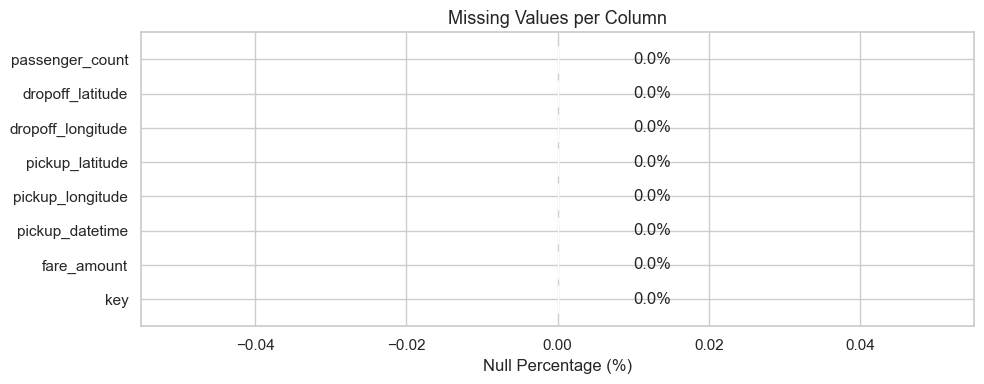

In [21]:
# Visualize missing values
null_counts = pandas_df.isnull().sum()
null_percentages = (null_counts / len(pandas_df) * 100).round(2)

null_df_viz = pd.DataFrame({
    'Column': null_counts.index,
    'Percentage (%)': null_percentages.values
})

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(null_df_viz['Column'], null_df_viz['Percentage (%)'], color='steelblue')
ax.set_xlabel('Null Percentage (%)')
ax.set_title('Missing Values per Column')
for bar, val in zip(bars, null_df_viz['Percentage (%)']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center')
plt.tight_layout()
plt.savefig('../data/plots/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.3 Descriptive Statistics

In [9]:
# Descriptive statistics using pandas (data already loaded)
print('=== DESCRIPTIVE STATISTICS ===')
numeric_cols = ['fare_amount', 'pickup_longitude', 'pickup_latitude',
                'dropoff_longitude', 'dropoff_latitude', 'passenger_count']
print(pandas_df[numeric_cols].describe())

=== DESCRIPTIVE STATISTICS ===
        fare_amount  pickup_longitude  pickup_latitude  dropoff_longitude  \
count  50000.000000      50000.000000     50000.000000       50000.000000   
mean      11.364171        -72.509756        39.933759         -72.504616   
std        9.685557         10.393860         6.224857          10.407570   
min       -5.000000        -75.423848       -74.006893         -84.654241   
25%        6.000000        -73.992062        40.734880         -73.991152   
50%        8.500000        -73.981840        40.752678         -73.980082   
75%       12.500000        -73.967148        40.767360         -73.963584   
max      200.000000         40.783472       401.083332          40.851027   

       dropoff_latitude  passenger_count  
count      50000.000000     50000.000000  
mean          39.926251         1.667840  
std            6.014737         1.289195  
min          -74.006377         0.000000  
25%           40.734372         1.000000  
50%           40.

## 2.4 Fare Amount Distribution (Target Variable)

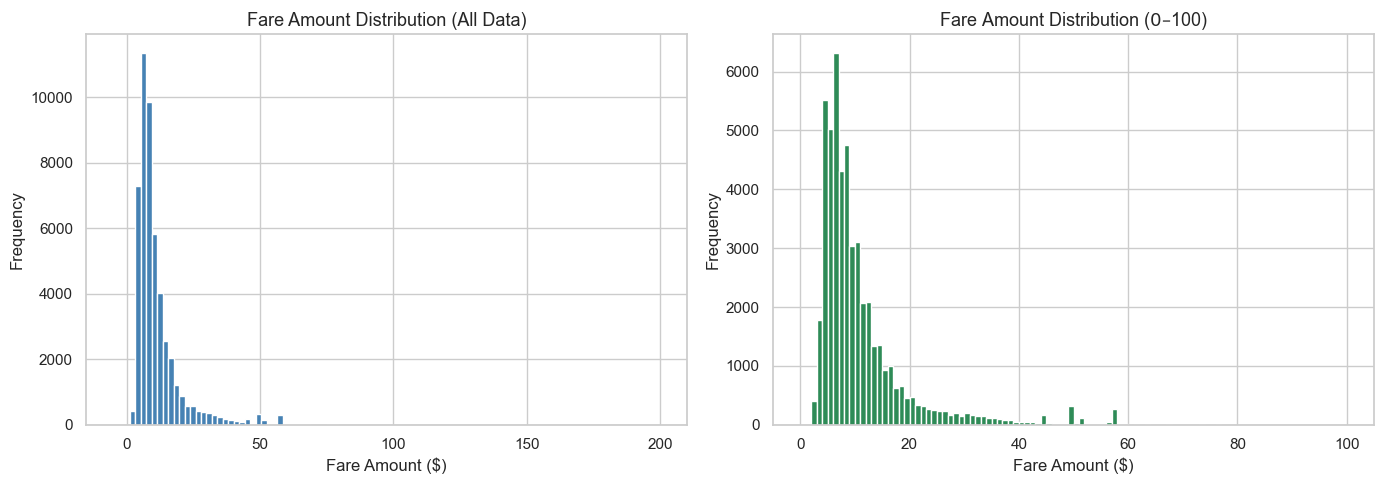

Min fare : $-5.00
Max fare : $200.00
Mean fare: $11.36
Median   : $8.50


In [10]:
# Fare Amount Distribution (Target Variable)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All data histogram
axes[0].hist(pandas_df['fare_amount'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Fare Amount Distribution (All Data)')
axes[0].set_xlabel('Fare Amount ($)')
axes[0].set_ylabel('Frequency')

# Filtered histogram (0-100$)
fare_filtered = pandas_df[(pandas_df['fare_amount'] > 0) & (pandas_df['fare_amount'] <= 100)]
axes[1].hist(fare_filtered['fare_amount'], bins=100, color='seagreen', edgecolor='white')
axes[1].set_title('Fare Amount Distribution ($0–$100)')
axes[1].set_xlabel('Fare Amount ($)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../data/plots/fare_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Min fare : ${pandas_df["fare_amount"].min():.2f}')
print(f'Max fare : ${pandas_df["fare_amount"].max():.2f}')
print(f'Mean fare: ${pandas_df["fare_amount"].mean():.2f}')
print(f'Median   : ${pandas_df["fare_amount"].median():.2f}')

In [11]:
# Outlier detection using IQR
q1 = pandas_df['fare_amount'].quantile(0.25)
q3 = pandas_df['fare_amount'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = len(pandas_df[(pandas_df['fare_amount'] < lower_bound) | (pandas_df['fare_amount'] > upper_bound)])
total = len(pandas_df)

print(f'Q1: ${q1:.2f} | Q3: ${q3:.2f} | IQR: ${iqr:.2f}')
print(f'Lower bound: ${lower_bound:.2f} | Upper bound: ${upper_bound:.2f}')
print(f'Outlier count: {outliers:,} ({outliers/total*100:.2f}%)')

Q1: $6.00 | Q3: $12.50 | IQR: $6.50
Lower bound: $-3.75 | Upper bound: $22.25
Outlier count: 4,365 (8.73%)


## 2.5 Passenger Count Distribution

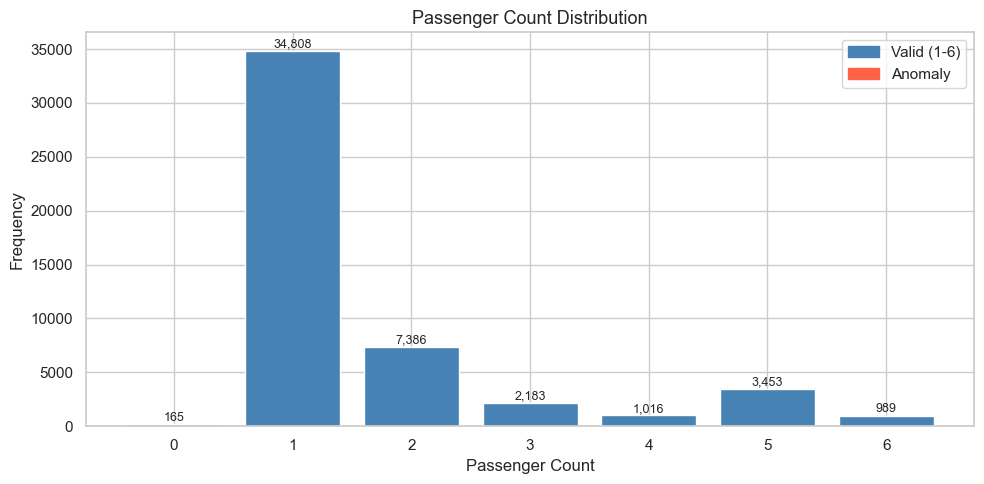

 passenger_count  count
               0    165
               1  34808
               2   7386
               3   2183
               4   1016
               5   3453
               6    989


In [12]:
# Passenger count distribution
passenger_dist = pandas_df['passenger_count'].value_counts().sort_index().reset_index()
passenger_dist.columns = ['passenger_count', 'count']

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['steelblue' if (1 <= x <= 6) else 'tomato'
          for x in passenger_dist['passenger_count']]
bars = ax.bar(passenger_dist['passenger_count'].astype(str),
              passenger_dist['count'], color=colors, edgecolor='white')
ax.set_title('Passenger Count Distribution')
ax.set_xlabel('Passenger Count')
ax.set_ylabel('Frequency')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 50, f'{int(h):,}',
            ha='center', va='bottom', fontsize=9)
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='steelblue', label='Valid (1-6)'),
    plt.Rectangle((0,0),1,1, color='tomato', label='Anomaly')
])
plt.tight_layout()
plt.savefig('../data/plots/passenger_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(passenger_dist.to_string(index=False))

## 2.6 Geographic Coordinates Analysis

In [13]:
# Valid NYC coordinate bounds
NYC_BOUNDS = {
    'lon_min': -74.3, 'lon_max': -72.9,
    'lat_min':  40.5, 'lat_max':  41.0
}

# Count coordinates outside NYC bounds
invalid_coords = len(pandas_df[
    (pandas_df['pickup_longitude'] < NYC_BOUNDS['lon_min']) |
    (pandas_df['pickup_longitude'] > NYC_BOUNDS['lon_max']) |
    (pandas_df['pickup_latitude'] < NYC_BOUNDS['lat_min']) |
    (pandas_df['pickup_latitude'] > NYC_BOUNDS['lat_max']) |
    (pandas_df['dropoff_longitude'] < NYC_BOUNDS['lon_min']) |
    (pandas_df['dropoff_longitude'] > NYC_BOUNDS['lon_max']) |
    (pandas_df['dropoff_latitude'] < NYC_BOUNDS['lat_min']) |
    (pandas_df['dropoff_latitude'] > NYC_BOUNDS['lat_max'])
])

total = len(pandas_df)
print(f'Coordinates outside NYC bounds: {invalid_coords:,} ({invalid_coords/total*100:.2f}%)')

Coordinates outside NYC bounds: 1,094 (2.19%)


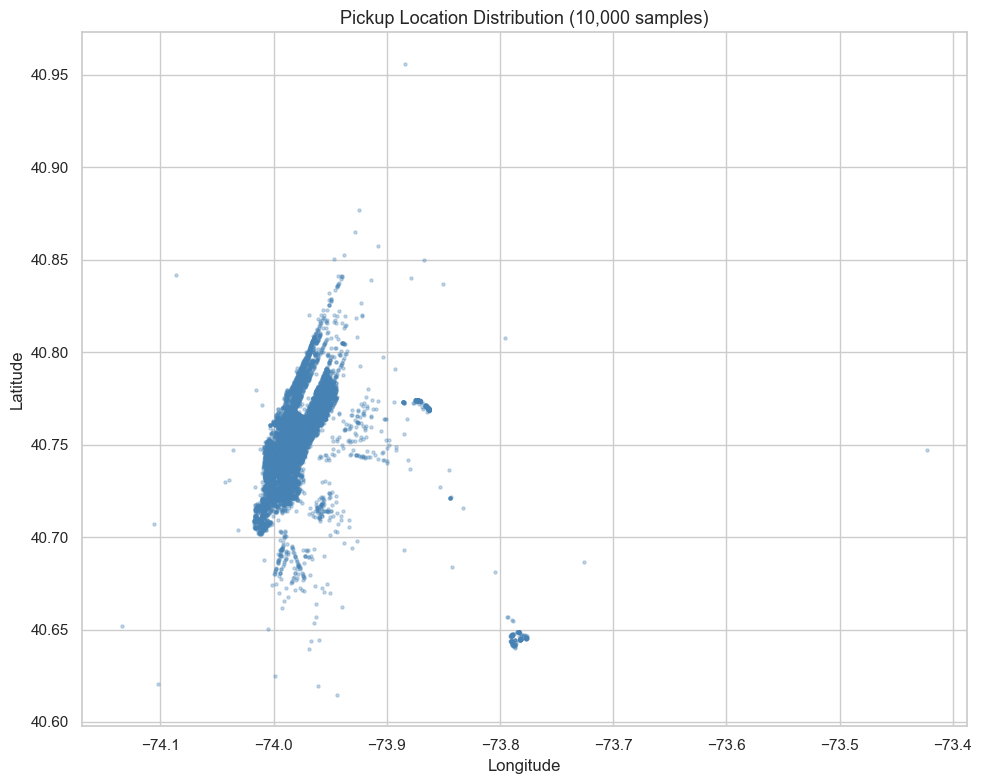

In [14]:
# Scatter plot of pickup locations within NYC
coords_pd = pandas_df[
    (pandas_df['pickup_longitude'].between(NYC_BOUNDS['lon_min'], NYC_BOUNDS['lon_max'])) &
    (pandas_df['pickup_latitude'].between(NYC_BOUNDS['lat_min'], NYC_BOUNDS['lat_max']))
].head(10000)

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(coords_pd['pickup_longitude'], coords_pd['pickup_latitude'],
           alpha=0.3, s=5, color='steelblue')
ax.set_title('Pickup Location Distribution (10,000 samples)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('../data/plots/pickup_locations.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.7 Temporal Analysis

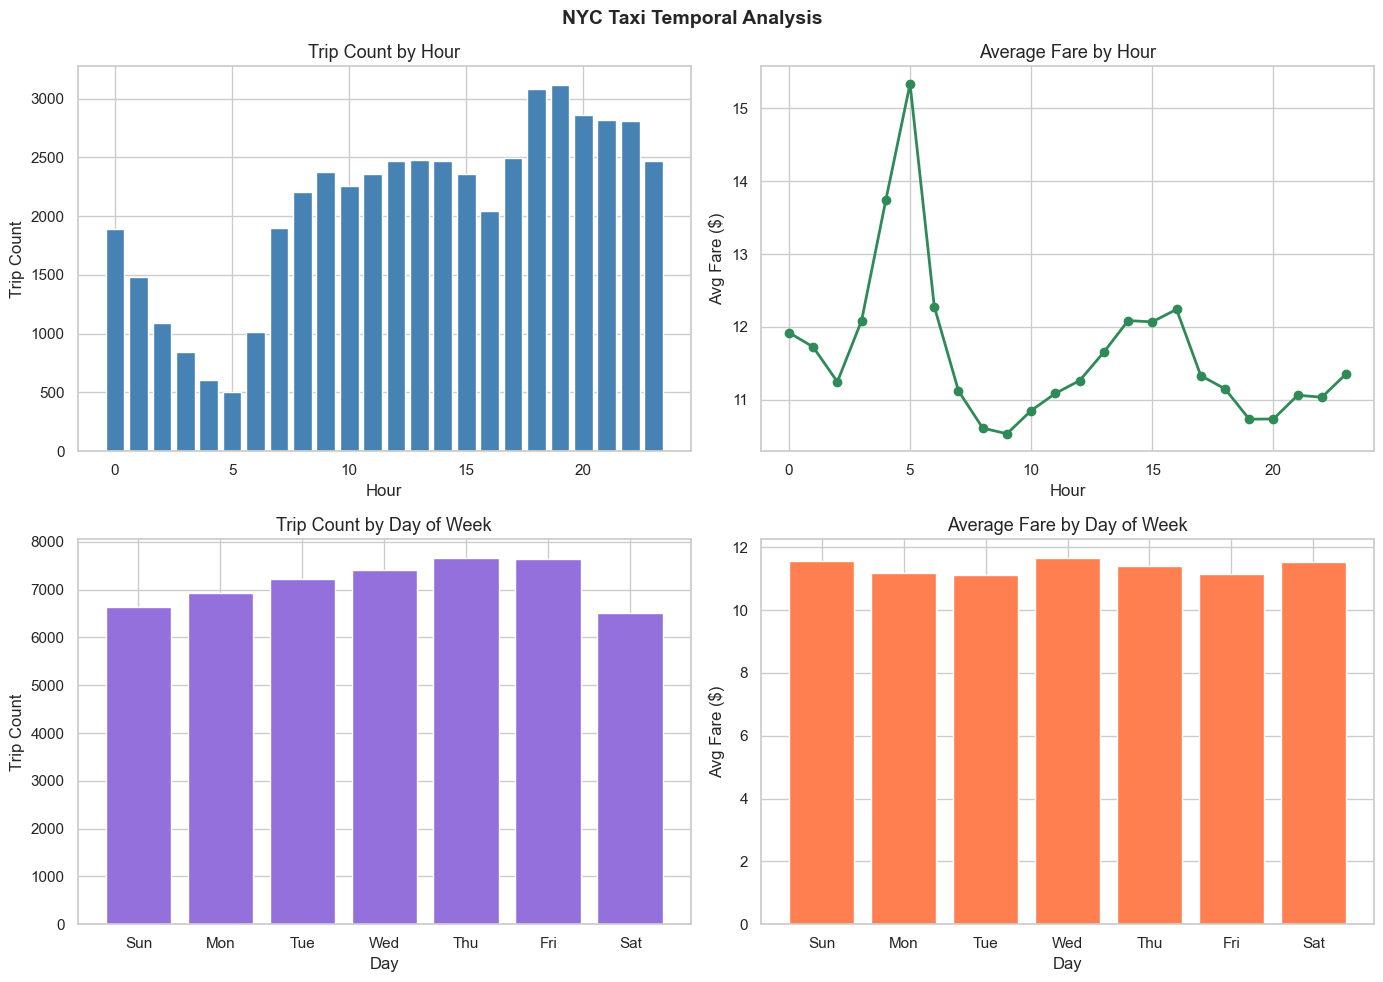

In [15]:
# Extract time features
df_time = pandas_df.copy()
df_time['year'] = df_time['pickup_datetime'].dt.year
df_time['month'] = df_time['pickup_datetime'].dt.month
df_time['hour'] = df_time['pickup_datetime'].dt.hour
df_time['day_of_week'] = df_time['pickup_datetime'].dt.dayofweek

# Average fare by hour
fare_by_hour = df_time.groupby('hour').agg({'fare_amount': 'mean', 'key': 'count'}).reset_index()
fare_by_hour.columns = ['hour', 'avg_fare', 'trip_count']

# Average fare by day of week
days = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
fare_by_day = df_time.groupby('day_of_week').agg({'fare_amount': 'mean', 'key': 'count'}).reset_index()
fare_by_day.columns = ['day_of_week', 'avg_fare', 'trip_count']
fare_by_day['day_name'] = fare_by_day['day_of_week'].apply(lambda x: days[x])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0][0].bar(fare_by_hour['hour'], fare_by_hour['trip_count'],
               color='steelblue', edgecolor='white')
axes[0][0].set_title('Trip Count by Hour')
axes[0][0].set_xlabel('Hour')
axes[0][0].set_ylabel('Trip Count')

axes[0][1].plot(fare_by_hour['hour'], fare_by_hour['avg_fare'],
                marker='o', color='seagreen', linewidth=2)
axes[0][1].set_title('Average Fare by Hour')
axes[0][1].set_xlabel('Hour')
axes[0][1].set_ylabel('Avg Fare ($)')

axes[1][0].bar(fare_by_day['day_name'], fare_by_day['trip_count'],
               color='mediumpurple', edgecolor='white')
axes[1][0].set_title('Trip Count by Day of Week')
axes[1][0].set_xlabel('Day')
axes[1][0].set_ylabel('Trip Count')

axes[1][1].bar(fare_by_day['day_name'], fare_by_day['avg_fare'],
               color='coral', edgecolor='white')
axes[1][1].set_title('Average Fare by Day of Week')
axes[1][1].set_xlabel('Day')
axes[1][1].set_ylabel('Avg Fare ($)')

plt.suptitle('NYC Taxi Temporal Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/plots/temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.8 Yearly Trend Analysis

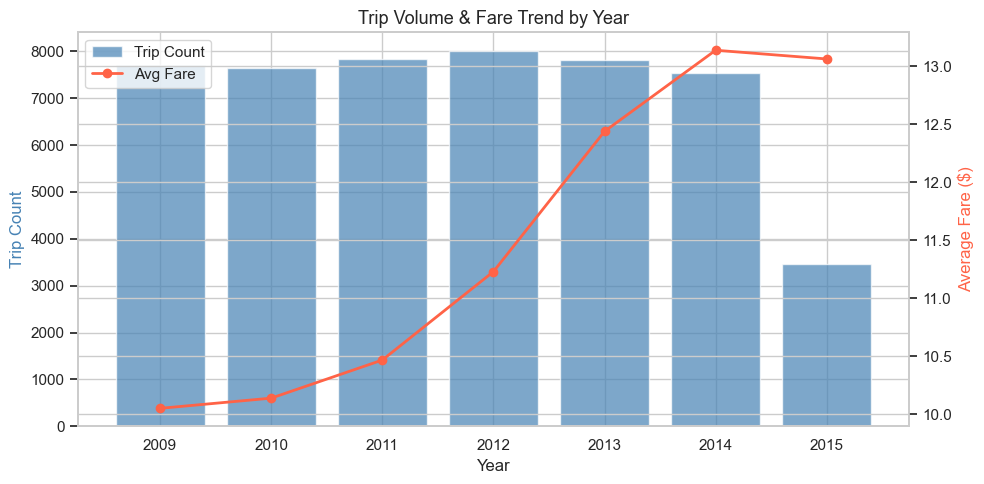

In [16]:
fare_by_year = df_time.groupby('year').agg({'fare_amount': 'mean', 'key': 'count'}).reset_index()
fare_by_year.columns = ['year', 'avg_fare', 'trip_count']
fare_by_year = fare_by_year.dropna()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.bar(fare_by_year['year'].astype(str), fare_by_year['trip_count'],
        color='steelblue', alpha=0.7, label='Trip Count')
ax2.plot(fare_by_year['year'].astype(str), fare_by_year['avg_fare'],
         color='tomato', marker='o', linewidth=2, label='Avg Fare')

ax1.set_xlabel('Year')
ax1.set_ylabel('Trip Count', color='steelblue')
ax2.set_ylabel('Average Fare ($)', color='tomato')
plt.title('Trip Volume & Fare Trend by Year')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../data/plots/yearly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.9 Correlation Analysis

In [17]:
# Compute correlation with fare_amount
print('=== CORRELATION WITH FARE_AMOUNT ===')
for col in ['pickup_longitude', 'pickup_latitude',
            'dropoff_longitude', 'dropoff_latitude', 'passenger_count']:
    corr = pandas_df['fare_amount'].corr(pandas_df[col])
    print(f'  fare_amount vs {col:25s}: {corr:+.4f}')

=== CORRELATION WITH FARE_AMOUNT ===
  fare_amount vs pickup_longitude         : +0.0059
  fare_amount vs pickup_latitude          : -0.0073
  fare_amount vs dropoff_longitude        : +0.0043
  fare_amount vs dropoff_latitude         : -0.0054
  fare_amount vs passenger_count          : +0.0166


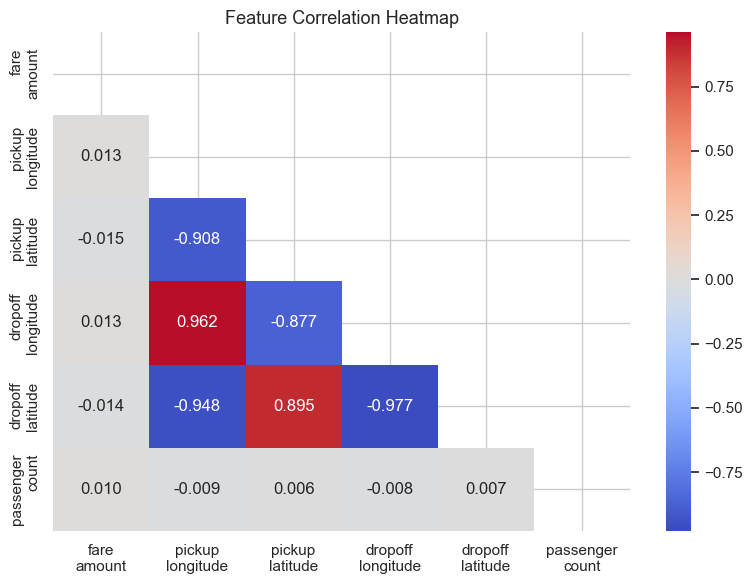

In [18]:
# Correlation heatmap
corr_cols = ['fare_amount', 'pickup_longitude', 'pickup_latitude',
             'dropoff_longitude', 'dropoff_latitude', 'passenger_count']
corr_pd = pandas_df[corr_cols].dropna().head(20000)

fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = corr_pd.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f',
            cmap='coolwarm', center=0, ax=ax,
            xticklabels=[c.replace('_', '\n') for c in corr_cols],
            yticklabels=[c.replace('_', '\n') for c in corr_cols])
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('../data/plots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.10 EDA Key Findings

| Finding | Details |
|---------|---------|
| Total data | 50,000 rows |
| Missing values | Present in some coordinate & passenger_count columns |
| Fare outliers | Negative values and very large fares exist (need filtering) |
| Passenger anomalies | Values of 0 and >6 need to be removed |
| Invalid coordinates | Some coordinates fall outside NYC bounds |
| Time patterns | Peak hours in morning & evening; higher fares on weekends |
| Yearly trend | Trip volume increased from 2009–2015 |

**Key insight:** Trip distance is likely the strongest predictor of fare, but it's not directly available — it must be calculated from coordinates in the preprocessing stage.

In [20]:
print('Notebook 02 (EDA) complete!')
# spark.stop()

Notebook 02 (EDA) complete!
